# Hyperparameter Tuning, Final Evaluation, and SHAP Explainability

### AAI-590 Capstone Project - University of San Diego
### Team Members:
 - Jamshed Nabizada
 - Swapnil Patil

## Purpose

This notebook performs hyperparameter tuning on the selected XGBoost model from Notebook 03, evaluates the optimized model on the held-out test set, and applies SHAP-based explainability to understand which features drive NOVA food processing classification predictions.

**Workflow:**
1. Load prepared data splits and the baseline XGBoost configuration from previous notebooks
2. Perform Bayesian hyperparameter optimization using Optuna with early stopping to improve Macro F1
3. Train the final tuned model on the full training data
4. Evaluate on the held-out test set (first and only use of test data)
5. Compare baseline vs. tuned performance
6. Apply SHAP explainability to interpret model decisions at both global and class levels

## Environment Setup and Configuration

In [3]:
%pip install -q -r requirements.txt lightgbm optuna shap

Note: you may need to restart the kernel to use updated packages.


In [4]:
# suppress warnings for cleaner notebook output
import warnings
warnings.filterwarnings("ignore")

# force-reload src.modeling modules so code changes are always picked up
%load_ext autoreload
%autoreload 2

import json
import gc
import time
from pathlib import Path
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import shap
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from IPython.display import display

from src.modeling import (
    ARTIFACTS_DIR,
    N_CLASSES,
    NOVA_LABELS,
    PRIMARY_METRIC,
    RANDOM_STATE,
    RESULTS_DIR,
    HyperparameterTuner,
    MetricsEvaluator,
    ModelPlotter,
    ModelResult,
    ModelRunner,
)

np.random.seed(RANDOM_STATE)

## Load Prepared Data

Load the train/validation/test splits, feature names, class weights, and scaler produced by the Feature Engineering notebook (Notebook 02), along with the model selection metadata from the Model Training notebook (Notebook 03).

In [5]:
# load saved splits and metadata from Feature Engineering notebook (Notebook 02)
splits = joblib.load(ARTIFACTS_DIR / "data_splits.joblib")

# unpack train/validation/test splits
X_train = splits["X_train"]
X_val = splits["X_val"]
X_test = splits["X_test"]
y_train = splits["y_train"]
y_val = splits["y_val"]
y_test = splits["y_test"]

# feature names and class weights from feature engineering
feature_names = splits["feature_names"]
class_weights_dict = splits["class_weights"]

# load model selection metadata from Notebook 03
with open(RESULTS_DIR / "selected_model_meta.json") as f:
    selection_meta = json.load(f)

print(f"Selected model: {selection_meta['selected_model']}")
print(f"Baseline {PRIMARY_METRIC}: {selection_meta['primary_metric_value']:.4f}")
print(f"Features ({len(feature_names)}): {feature_names}")
print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Selected model: XGBoost
Baseline Macro F1: 0.8561
Features (20): ['energy_100g', 'fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'saturated_fat_100g', 'additives_n', 'trans_fat_100g', 'added_sugars_100g', 'monounsaturated_fat_100g', 'polyunsaturated_fat_100g', 'starch_100g', 'nutriscore_score', 'sugar_fiber_ratio', 'fat_protein_ratio', 'additives_per_energy', 'trans_fat_ratio', 'unsaturated_fat_ratio']
Train: (134343, 20)  Val: (44781, 20)  Test: (44782, 20)


In [6]:
# per-sample weights for XGBoost training (inverse frequency-based)
train_sample_weights = compute_sample_weight("balanced", y_train)

# verify class distributions across splits
for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = y.value_counts().sort_index()
    pcts = (counts / len(y) * 100).round(1)
    dist = ", ".join(f"NOVA {i+1}: {c:,} ({pcts[i]}%)" for i, c in counts.items())
    print(f"{name:5s} ({len(y):,}) -- {dist}")

Train (134,343) -- NOVA 1: 16,129 (12.0%), NOVA 2: 4,931 (3.7%), NOVA 3: 26,974 (20.1%), NOVA 4: 86,309 (64.2%)
Val   (44,781) -- NOVA 1: 5,376 (12.0%), NOVA 2: 1,644 (3.7%), NOVA 3: 8,991 (20.1%), NOVA 4: 28,770 (64.2%)
Test  (44,782) -- NOVA 1: 5,377 (12.0%), NOVA 2: 1,643 (3.7%), NOVA 3: 8,992 (20.1%), NOVA 4: 28,770 (64.2%)


---
## Baseline XGBoost Performance

First, retrain the XGBoost model with the same configuration used in Notebook 03 to establish the baseline performance that the hyperparameter tuning should improve upon.

In [7]:
# instantiate shared evaluation objects
evaluator = MetricsEvaluator(labels=NOVA_LABELS, n_classes=N_CLASSES)
runner = ModelRunner(evaluator=evaluator)
plotter = ModelPlotter()

# baseline XGBoost with the same parameters from Notebook 03
xgb_baseline = XGBClassifier(
    objective="multi:softprob",
    num_class=N_CLASSES,
    eval_metric="mlogloss",
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    tree_method="hist",
    random_state=RANDOM_STATE,
    verbosity=0,
)

baseline_result = runner.run(
    name="XGBoost (Baseline)",
    model=xgb_baseline,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    fit_kwargs={
        "sample_weight": train_sample_weights,
        "eval_set": [(X_val, y_val)],
        "verbose": False,
    },
)

print(f"Baseline XGBoost -- Macro F1: {baseline_result.metrics['Macro F1']:.4f}  "
      f"Balanced Acc: {baseline_result.metrics['Balanced Accuracy']:.4f}  "
      f"Train: {baseline_result.metrics['Train Time (s)']:.1f}s")
display(baseline_result.per_class)

Baseline XGBoost -- Macro F1: 0.8561  Balanced Acc: 0.8824  Train: 10.5s


,Class,Precision,Recall,F1,Support
0,NOVA 1,0.801262,0.920945,0.856945,5376.0
1,NOVA 2,0.878190,0.920925,0.899050,1644.0
2,NOVA 3,0.706942,0.807585,0.753920,8991.0
3,NOVA 4,0.951592,0.880049,0.914423,28770.0


---
## Hyperparameter Tuning with Optuna

Bayesian optimization via Optuna is used to search for the best XGBoost hyperparameters. The objective maximizes Macro F1 on the validation set, which is aligned with the primary evaluation metric used throughout the project. Early stopping halts boosting when validation loss stops improving, preventing overfitting and reducing wasted computation.

The search space covers structural parameters (tree depth, max leaves, number of estimators), regularization parameters (L1/L2, min child weight, gamma, max_delta_step), and stochastic parameters (subsampling at tree, level, and node granularity) that control the bias-variance tradeoff in gradient-boosted trees. The expanded search space and increased trial count give Optuna more room to find stronger configurations.

In [8]:
# initialize the tuner with early stopping (stops boosting when val loss plateaus)
tuner = HyperparameterTuner(
    n_classes=N_CLASSES,
    random_state=RANDOM_STATE,
    early_stopping_rounds=50,
)

In [9]:
# run Bayesian hyperparameter search (75 trials for broader exploration)
tuning_result = tuner.tune(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    sample_weight=train_sample_weights,
    n_trials=30,
    baseline_score=baseline_result.metrics["Macro F1"],
)

print(f"\nBest trial: #{tuning_result.study.best_trial.number}")
print(f"Best Macro F1: {tuning_result.best_score:.4f}")
print(f"Baseline Macro F1: {tuning_result.baseline_score:.4f}")
print(f"Improvement: {tuning_result.improvement:+.4f}")
print(f"\nBest hyperparameters:")
for k, v in tuning_result.best_params.items():
    print(f"  {k}: {v}")

Best trial: 28. Best value: 0.85706: 100%|██████████| 30/30 [11:37<00:00, 23.26s/it]


Best trial: #28
Best Macro F1: 0.8571
Baseline Macro F1: 0.8561
Improvement: +0.0010

Best hyperparameters:
  n_estimators: 1450
  max_depth: 10
  learning_rate: 0.0672265139552494
  max_leaves: 181
  min_child_weight: 3
  reg_alpha: 0.0026268537269584433
  reg_lambda: 0.0012668861795320405
  gamma: 0.3315749044878783
  max_delta_step: 1
  subsample: 0.6674855217179587
  colsample_bytree: 0.9564715588013275
  colsample_bylevel: 0.8468983274631778
  colsample_bynode: 0.6249540787327926


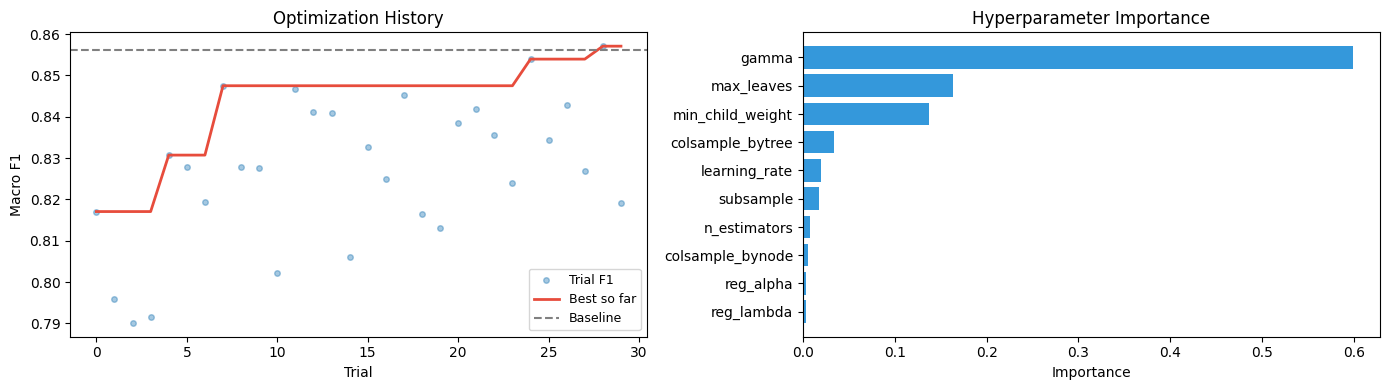

In [10]:
# optimization history and hyperparameter importance
plotter.plot_optimization_history(tuning_result)

---
## Train Final Tuned Model

Train the XGBoost model with the best hyperparameters found by Optuna. This model will be evaluated on the validation set first to confirm improvement, and then on the held-out test set for the final unbiased evaluation.

In [11]:
# build the tuned model from the best parameters (includes early stopping)
xgb_tuned = tuner.build_tuned_model(tuning_result.best_params)

# evaluate on validation set using the shared pipeline
tuned_result = runner.run(
    name="XGBoost (Tuned)",
    model=xgb_tuned,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    fit_kwargs={
        "sample_weight": train_sample_weights,
        "eval_set": [(X_val, y_val)],
        "verbose": False,
    },
)

print(f"Tuned XGBoost -- Macro F1: {tuned_result.metrics['Macro F1']:.4f}  "
      f"Balanced Acc: {tuned_result.metrics['Balanced Accuracy']:.4f}  "
      f"Train: {tuned_result.metrics['Train Time (s)']:.1f}s")
display(tuned_result.per_class)

Tuned XGBoost -- Macro F1: 0.8571  Balanced Acc: 0.8807  Train: 23.2s


,Class,Precision,Recall,F1,Support
0,NOVA 1,0.806727,0.914621,0.857292,5376.0
1,NOVA 2,0.878472,0.923358,0.900356,1644.0
2,NOVA 3,0.715383,0.797575,0.754247,8991.0
3,NOVA 4,0.947576,0.887105,0.916344,28770.0


In [12]:
# side-by-side comparison of baseline vs. tuned on validation set
comparison_rows = []
for res in [baseline_result, tuned_result]:
    row = {"Model": res.name}
    row.update(res.metrics)
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)

print("Baseline vs. Tuned (Validation Set)")
display(comparison_df.style.format({
    c: "{:.4f}" for c in comparison_df.columns if c != "Model"
}).highlight_max(
    subset=[PRIMARY_METRIC, "Balanced Accuracy", "Weighted F1"],
    color="#f7376d"
))

Baseline vs. Tuned (Validation Set)


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Log Loss,ROC-AUC (OVR),Train Time (s),Inference Time (s)
0,XGBoost (Baseline),0.8719,0.8824,0.8345,0.8824,0.8561,0.8817,0.8719,0.8747,0.3287,0.9735,10.4800,0.1896
1,XGBoost (Tuned),0.8738,0.8807,0.8370,0.8807,0.8571,0.8815,0.8738,0.8761,0.3244,0.9741,23.2500,0.3825


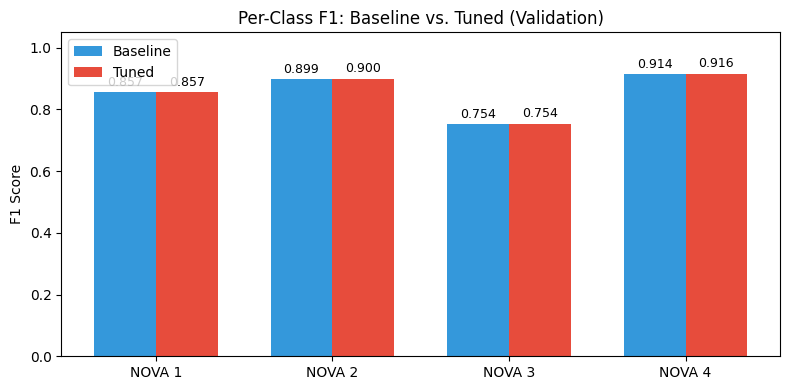

In [13]:
# per-class F1 comparison: baseline vs. tuned
plotter.plot_baseline_vs_tuned(baseline_result, tuned_result, NOVA_LABELS)

---
## Final Test Set Evaluation

The test set is used here for the first and only time to provide an unbiased estimate of the tuned model's generalization performance. No model selection decisions are made based on these results.

In [14]:
# evaluate the tuned model on the held-out test set
t0 = time.perf_counter()
y_test_pred = xgb_tuned.predict(X_test)
test_inference_time = time.perf_counter() - t0

y_test_proba = xgb_tuned.predict_proba(X_test)

# compute test metrics using the shared evaluator
test_metrics, test_per_class, test_cm, test_report = evaluator.evaluate(
    y_test, y_test_pred, y_test_proba
)
test_metrics["Inference Time (s)"] = round(test_inference_time, 4)

print("Final Test Set Results (XGBoost Tuned)")
print(f"  Macro F1:          {test_metrics['Macro F1']:.4f}")
print(f"  Balanced Accuracy: {test_metrics['Balanced Accuracy']:.4f}")
print(f"  Weighted F1:       {test_metrics['Weighted F1']:.4f}")
print(f"  Accuracy:          {test_metrics['Accuracy']:.4f}")
if "Log Loss" in test_metrics:
    print(f"  Log Loss:          {test_metrics['Log Loss']:.4f}")
if "ROC-AUC (OVR)" in test_metrics:
    print(f"  ROC-AUC (OVR):     {test_metrics['ROC-AUC (OVR)']:.4f}")

print("\nPer-Class Metrics (Test Set):")
display(test_per_class)

Final Test Set Results (XGBoost Tuned)
  Macro F1:          0.8571
  Balanced Accuracy: 0.8823
  Weighted F1:       0.8784
  Accuracy:          0.8760
  Log Loss:          0.3231
  ROC-AUC (OVR):     0.9743

Per-Class Metrics (Test Set):


,Class,Precision,Recall,F1,Support
0,NOVA 1,0.806770,0.913149,0.856669,5377.0
1,NOVA 2,0.866933,0.923920,0.894520,1643.0
2,NOVA 3,0.717808,0.802825,0.757940,8992.0
3,NOVA 4,0.951428,0.889190,0.919257,28770.0


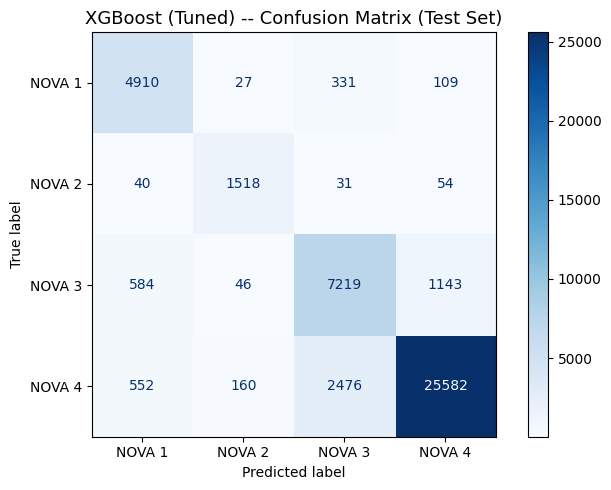

In [15]:
# confusion matrix for the final test set evaluation
plotter.plot_confusion_matrix(test_cm, NOVA_LABELS, "XGBoost (Tuned) -- Confusion Matrix (Test Set)")

In [16]:
# compare validation vs. test performance to check for overfitting
val_vs_test = pd.DataFrame([
    {"Split": "Validation", **{k: v for k, v in tuned_result.metrics.items() if k != "Train Time (s)"}},
    {"Split": "Test", **{k: v for k, v in test_metrics.items()}},
])

print("Validation vs. Test Performance (Tuned Model)")
display(val_vs_test.style.format({
    c: "{:.4f}" for c in val_vs_test.columns if c != "Split"
}))

Validation vs. Test Performance (Tuned Model)


,Split,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Log Loss,ROC-AUC (OVR),Inference Time (s)
0,Validation,0.8738,0.8807,0.8370,0.8807,0.8571,0.8815,0.8738,0.8761,0.3244,0.9741,0.3825
1,Test,0.8760,0.8823,0.8357,0.8823,0.8571,0.8840,0.8760,0.8784,0.3231,0.9743,0.3122


### Sample Predictions

Random test samples showing the model's actual predictions alongside true NOVA labels, predicted probabilities, and the input feature values. This provides a concrete view of how the model classifies individual food products.

In [17]:
# pick random test samples (reproducible) and show actual vs. predicted NOVA class
rng = np.random.RandomState(RANDOM_STATE)
sample_indices = rng.choice(len(X_test), size=10, replace=False)

sample_df = X_test.iloc[sample_indices].copy()
sample_df.insert(0, "True NOVA", [NOVA_LABELS[y] for y in y_test.iloc[sample_indices]])
sample_df.insert(1, "Predicted NOVA", [NOVA_LABELS[y] for y in y_test_pred[sample_indices]])
sample_df.insert(2, "Correct", sample_df["True NOVA"] == sample_df["Predicted NOVA"])

# add predicted probabilities for each class
proba_cols = {label: y_test_proba[sample_indices, i] for i, label in enumerate(NOVA_LABELS)}
for label, probs in proba_cols.items():
    sample_df[f"P({label})"] = probs

correct_count = sample_df["Correct"].sum()
print(f"Sample Predictions ({correct_count}/10 correct)")
display(
    sample_df.style
    .format({f"P({l})": "{:.3f}" for l in NOVA_LABELS})
    .format({c: "{:.2f}" for c in feature_names})
    .map(lambda v: "color: green" if v is True else "color: red", subset=["Correct"])
)

Sample Predictions (8/10 correct)


,True NOVA,Predicted NOVA,Correct,energy_100g,fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,saturated_fat_100g,additives_n,trans_fat_100g,added_sugars_100g,monounsaturated_fat_100g,polyunsaturated_fat_100g,starch_100g,nutriscore_score,sugar_fiber_ratio,fat_protein_ratio,additives_per_energy,trans_fat_ratio,unsaturated_fat_ratio,P(NOVA 1),P(NOVA 2),P(NOVA 3),P(NOVA 4)
214975,NOVA 4,NOVA 4,True,1885.20,14.10,75.80,69.40,3.20,2.90,0.01,8.10,2.00,0.00,55.00,1.04,1.25,0.09,8.00,21.69,4.86,0.00,0.00,0.16,0.000001,0.000003,0.000740,0.999256
121907,NOVA 4,NOVA 4,True,275.00,3.10,0.70,0.50,0.00,8.70,5.00,0.70,4.00,0.00,0.00,1.04,1.25,0.09,20.00,50000.00,0.36,0.01,0.00,0.74,0.000066,0.000003,0.005554,0.994377
135349,NOVA 4,NOVA 3,False,267.08,2.76,7.96,0.56,0.39,1.56,0.05,0.86,0.00,0.00,0.00,1.04,1.25,0.09,8.00,1.44,1.77,0.00,0.00,0.83,0.021511,0.002438,0.815271,0.160780
132752,NOVA 3,NOVA 3,True,1058.50,8.30,31.90,2.50,0.00,12.30,1.30,4.80,0.00,0.00,0.00,1.04,1.25,0.09,13.00,250000.00,0.67,0.00,0.00,0.28,0.016324,0.000036,0.845387,0.138253
99468,NOVA 3,NOVA 3,True,648.00,6.70,0.40,0.40,0.00,23.00,3.00,1.30,0.00,0.00,0.00,1.04,1.25,0.09,16.00,40000.00,0.29,0.00,0.00,0.34,0.002595,0.000003,0.994859,0.002543
70189,NOVA 4,NOVA 4,True,198.20,1.70,6.20,4.40,1.40,1.10,0.93,0.20,2.00,0.00,0.00,1.04,1.25,0.09,0.00,3.14,1.55,0.01,0.00,1.35,0.001003,0.000006,0.061724,0.937267
27785,NOVA 4,NOVA 3,False,1079.57,0.89,51.79,1.79,1.80,8.93,1.47,0.00,0.00,0.00,0.00,1.04,1.25,30.17,7.00,0.99,0.10,0.00,0.00,2.57,0.008787,0.000019,0.882838,0.108355
2296,NOVA 4,NOVA 4,True,1828.33,6.67,78.33,23.33,10.00,10.00,0.52,0.83,4.00,0.00,15.83,1.04,1.25,41.80,8.00,2.33,0.67,0.00,0.00,0.34,0.000003,0.000000,0.001766,0.998231
70337,NOVA 3,NOVA 3,True,1874.00,12.20,71.20,1.10,3.10,11.00,1.30,1.30,1.00,0.00,0.00,1.04,1.25,52.36,11.00,0.35,1.11,0.00,0.00,0.19,0.000261,0.000175,0.886011,0.113552
10476,NOVA 4,NOVA 4,True,2164.00,24.14,72.41,41.38,1.60,3.45,0.69,8.62,3.00,0.00,79.17,1.04,1.25,0.00,8.00,25.86,7.00,0.00,0.00,0.09,0.000000,0.000003,0.000319,0.999678


### Interpretation

The test set results should be compared to the validation performance to assess generalization. Consistency between validation and test metrics indicates that the model has not overfit to the validation set during hyperparameter tuning. Any significant drop in test performance relative to validation would suggest that the tuning process introduced some degree of overfitting to the validation data.

---
## SHAP Explainability

SHAP (SHapley Additive exPlanations) values are used to interpret the tuned XGBoost model by quantifying each feature's contribution to individual and aggregate predictions. This provides transparency into which nutritional and additive features are most important for distinguishing between NOVA food processing groups.

SHAP is applied to the validation set to explain the model's behavior on data it was not trained on, providing a more representative view of feature attribution than training-set explanations.

In [18]:
# compute SHAP values using TreeExplainer — lightweight shap_values() call only
explainer = shap.TreeExplainer(xgb_tuned)
X_val_np = X_val.values.astype(np.float64)

raw_shap = explainer.shap_values(X_val_np)

# diagnostic: inspect exactly what SHAP returned
print(f"Return type: {type(raw_shap)}")
if isinstance(raw_shap, list):
    print(f"List of {len(raw_shap)} arrays, shapes: {[np.array(a).shape for a in raw_shap]}")
    shap_values = [np.array(a) for a in raw_shap]
elif isinstance(raw_shap, np.ndarray):
    print(f"ndarray shape: {raw_shap.shape}")
    if raw_shap.ndim == 3:
        # (samples, features, classes) layout
        shap_values = [raw_shap[:, :, c].copy() for c in range(raw_shap.shape[2])]
    else:
        shap_values = [raw_shap.copy()]
else:
    raise TypeError(f"Unexpected SHAP return: {type(raw_shap)}")

n_features = X_val_np.shape[1]
n_samples = X_val_np.shape[0]

# trim offset column if SHAP appended one
for c in range(len(shap_values)):
    if shap_values[c].shape[1] > n_features:
        shap_values[c] = shap_values[c][:, :n_features]

# expected values for waterfall plots (scalar per class)
shap_expected = explainer.expected_value

# strict shape verification
for c, sv in enumerate(shap_values):
    assert sv.shape == (n_samples, n_features), \
        f"Class {c}: got {sv.shape}, expected ({n_samples}, {n_features})"
    print(f"  Class {c}: {sv.shape} OK")

print(f"\n{len(shap_values)} classes, {n_samples} samples, {n_features} features")
print(f"Expected values: {shap_expected}")

Return type: <class 'numpy.ndarray'>
ndarray shape: (44781, 20, 4)
  Class 0: (44781, 20) OK
  Class 1: (44781, 20) OK
  Class 2: (44781, 20) OK
  Class 3: (44781, 20) OK

4 classes, 44781 samples, 20 features
Expected values: [np.float32(-0.12362264), np.float32(0.26537356), np.float32(0.1202368), np.float32(-0.15966302)]


### Global Feature Importance

The summary bar plot shows the mean absolute SHAP value for each feature across all classes and all validation samples. Features with larger SHAP values have a greater influence on the model's predictions.

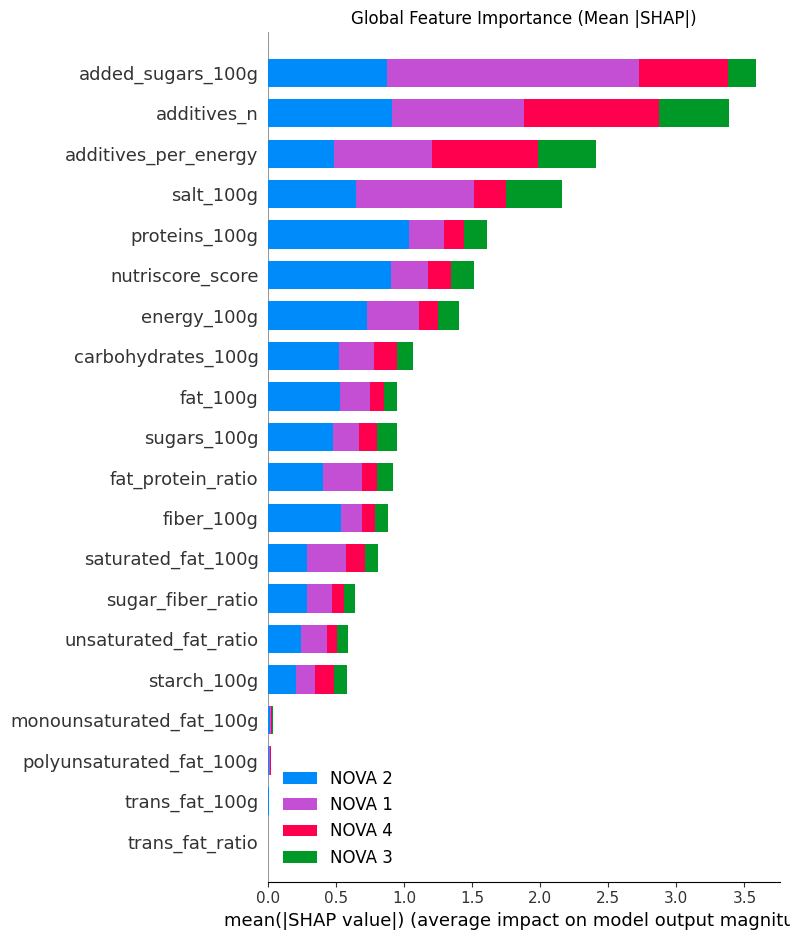

In [19]:
# global feature importance: mean |SHAP| across all classes
shap.summary_plot(
    shap_values,
    X_val_np,
    feature_names=feature_names,
    plot_type="bar",
    class_names=NOVA_LABELS,
    show=False,
    max_display=20,
)
plt.title("Global Feature Importance (Mean |SHAP|)")
plt.tight_layout()
plt.show()

### Per-Class SHAP Analysis

SHAP beeswarm plots for each NOVA class show how individual feature values affect the model's prediction for that specific class. Each dot represents one sample, with position on the x-axis indicating the SHAP value (positive = pushes toward this class) and color indicating the feature value (red = high, blue = low).


--- NOVA 1 --- shap: (44781, 20), data: (44781, 20)


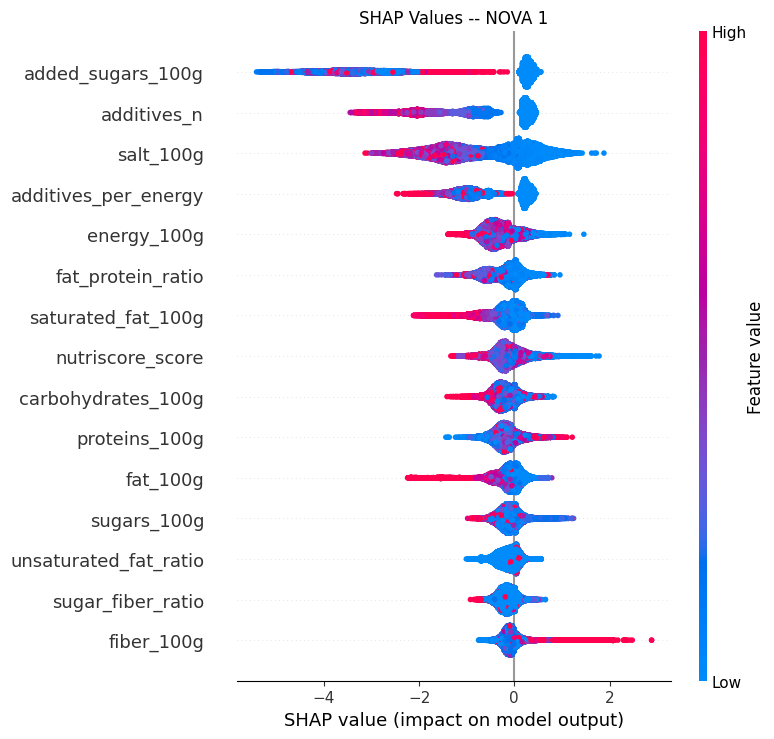


--- NOVA 2 --- shap: (44781, 20), data: (44781, 20)


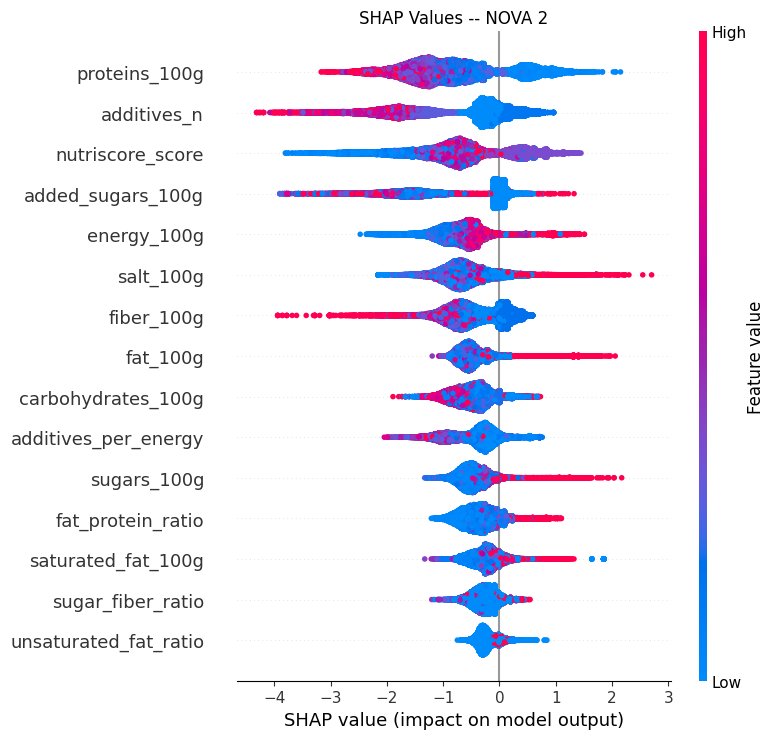


--- NOVA 3 --- shap: (44781, 20), data: (44781, 20)


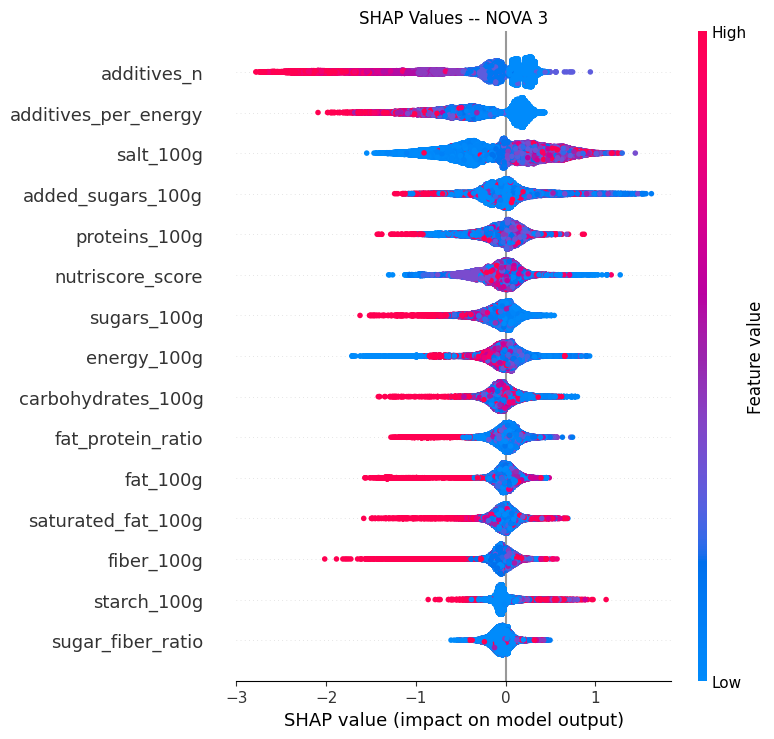


--- NOVA 4 --- shap: (44781, 20), data: (44781, 20)


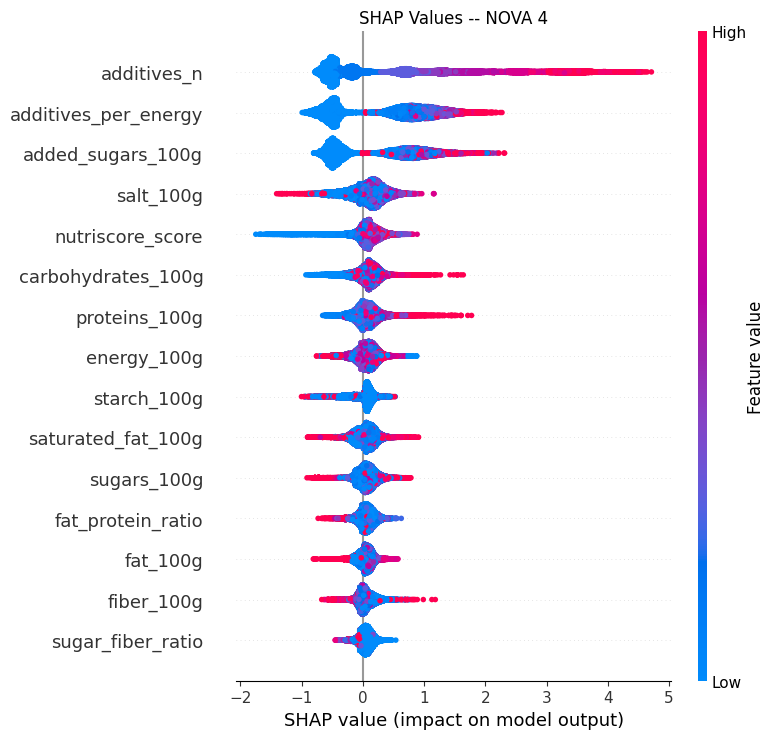

In [20]:
# per-class SHAP beeswarm plots
for i, label in enumerate(NOVA_LABELS):
    sv_i = np.ascontiguousarray(shap_values[i], dtype=np.float64)
    data_i = np.ascontiguousarray(X_val_np, dtype=np.float64)

    assert sv_i.shape == data_i.shape, \
        f"SHAPE MISMATCH for {label}: shap {sv_i.shape} != data {data_i.shape}"
    print(f"\n--- {label} --- shap: {sv_i.shape}, data: {data_i.shape}")

    shap.summary_plot(
        sv_i,
        data_i,
        feature_names=list(feature_names),
        show=False,
        max_display=15,
    )
    plt.title(f"SHAP Values -- {label}")
    plt.tight_layout()
    plt.show()

### SHAP Dependence Plots

Dependence plots reveal the relationship between a specific feature's value and its SHAP contribution for a given class. These plots help identify nonlinear effects, thresholds, and feature interactions that the model has learned.

Top 3 features for dependence analysis: ['added_sugars_100g', 'additives_n', 'additives_per_energy']


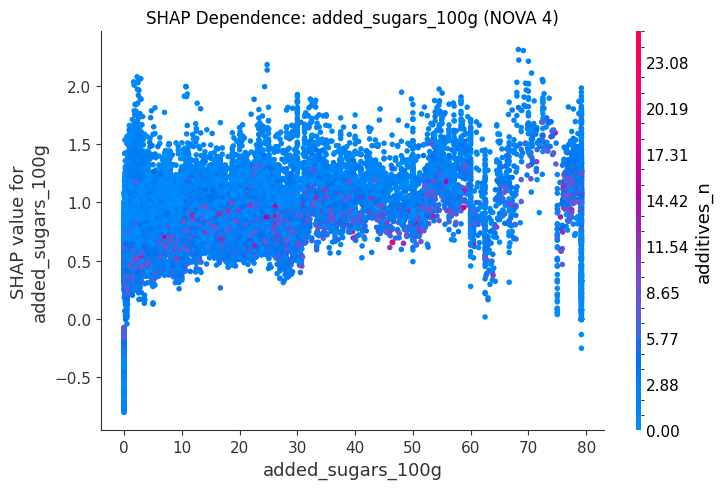

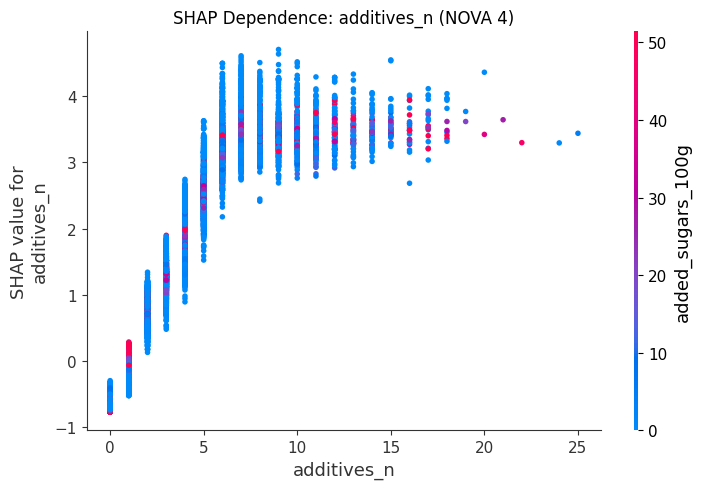

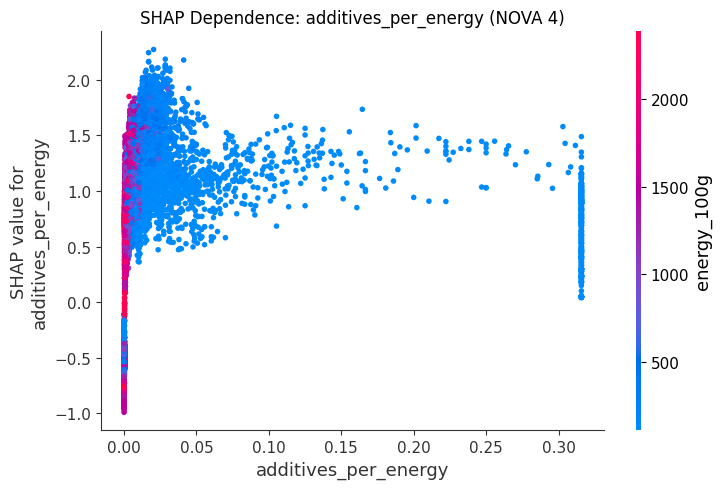

In [21]:
# identify top 3 most important features globally for dependence plots
mean_abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
top_feature_indices = np.argsort(mean_abs_shap)[::-1][:3]
top_features = [feature_names[i] for i in top_feature_indices]

print(f"Top 3 features for dependence analysis: {top_features}")

# dependence plots for NOVA 4 (majority class / ultra-processed)
nova4_idx = 3  # NOVA 4 = class index 3
for feat in top_features:
    shap.dependence_plot(
        feat,
        shap_values[nova4_idx],
        X_val_np,
        feature_names=feature_names,
        show=False,
    )
    plt.title(f"SHAP Dependence: {feat} (NOVA 4)")
    plt.tight_layout()
    plt.show()

### SHAP Waterfall: Individual Prediction Explanation

A waterfall plot decomposes a single prediction to show exactly how each feature contributes to the model's output for that specific sample. This provides transparency at the individual prediction level, which is important for understanding model behavior on specific food products.


--- NOVA 1 (sample #6) ---


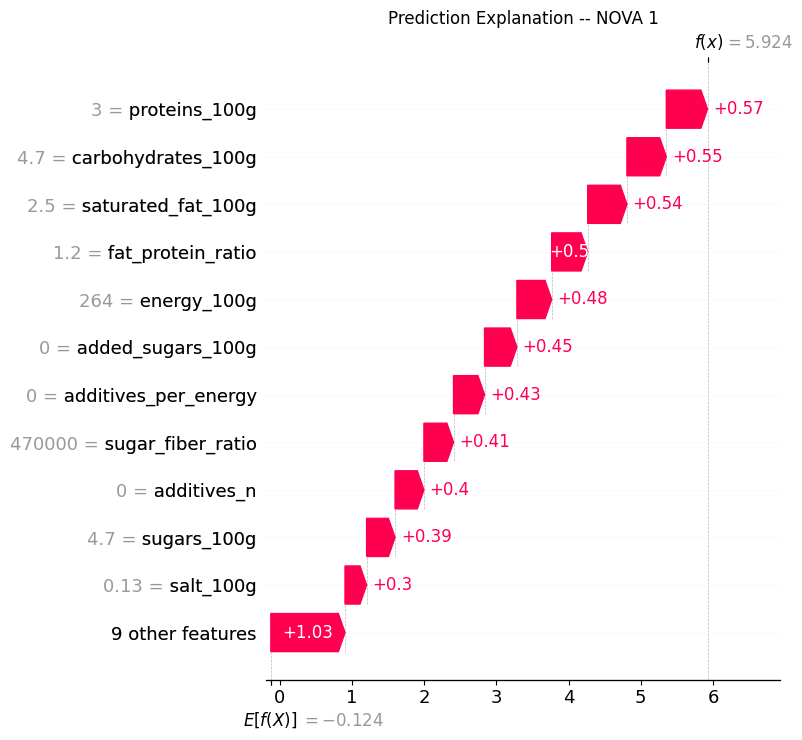


--- NOVA 2 (sample #31) ---


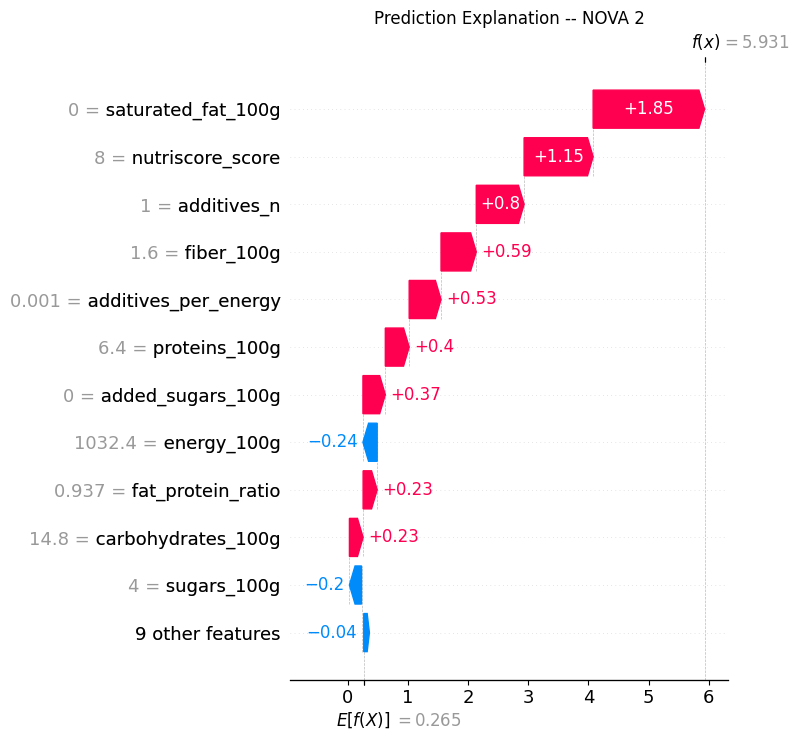


--- NOVA 3 (sample #2) ---


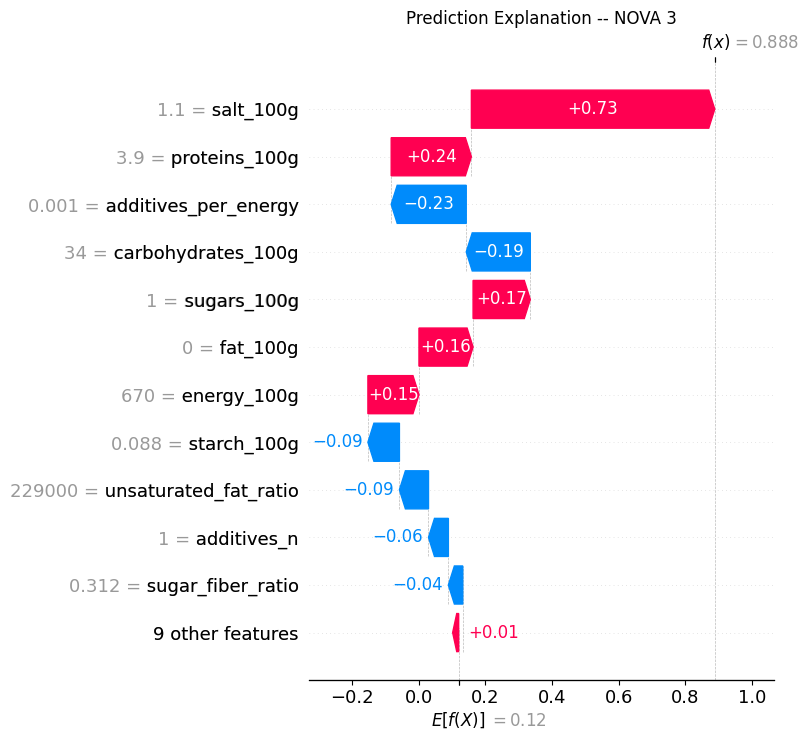


--- NOVA 4 (sample #0) ---


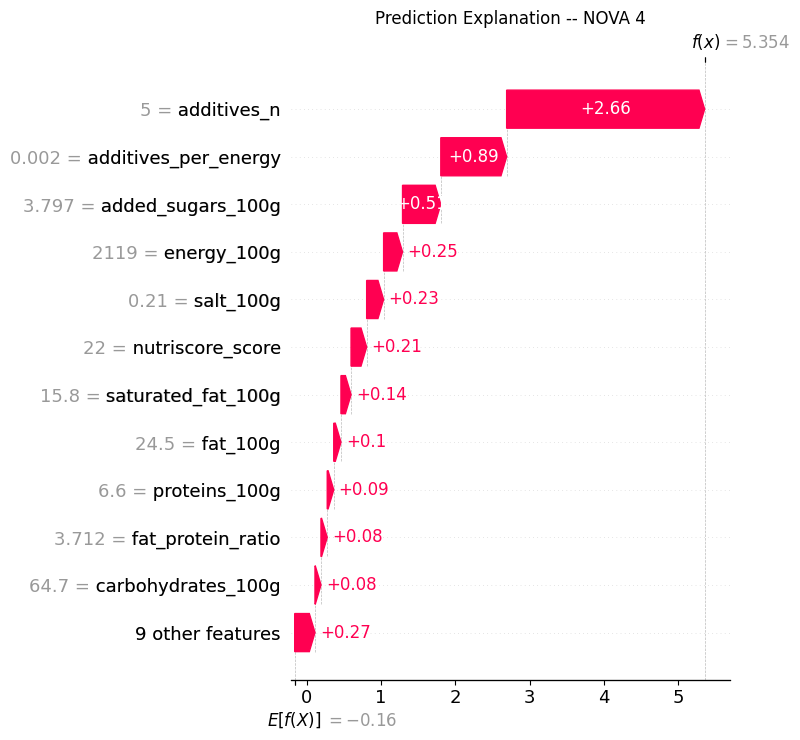

In [22]:
# select one representative sample from each NOVA class in the validation set
y_val_pred = xgb_tuned.predict(X_val_np)

for cls_idx, label in enumerate(NOVA_LABELS):
    # find a correctly predicted sample for this class
    mask = (y_val.values == cls_idx) & (y_val_pred == cls_idx)
    if mask.sum() == 0:
        print(f"No correctly predicted samples for {label}, skipping.")
        continue

    sample_idx = np.where(mask)[0][0]
    bv = shap_expected[cls_idx] if hasattr(shap_expected, '__len__') else shap_expected

    print(f"\n--- {label} (sample #{sample_idx}) ---")
    explanation = shap.Explanation(
        values=shap_values[cls_idx][sample_idx],
        base_values=bv,
        data=X_val_np[sample_idx],
        feature_names=list(feature_names),
    )
    shap.waterfall_plot(explanation, show=False, max_display=12)
    plt.title(f"Prediction Explanation -- {label}")
    plt.tight_layout()
    plt.show()

### SHAP Feature Importance Table

Tabular summary of mean absolute SHAP values per feature and per class, providing a precise numeric reference for the visual plots above.

In [23]:
# build a structured SHAP importance table
shap_importance_rows = []
for i, label in enumerate(NOVA_LABELS):
    mean_abs = np.abs(shap_values[i]).mean(axis=0)
    for j, feat in enumerate(feature_names):
        shap_importance_rows.append({
            "Feature": feat,
            "Class": label,
            "Mean |SHAP|": mean_abs[j],
        })

shap_df = pd.DataFrame(shap_importance_rows)
shap_pivot = shap_df.pivot_table(index="Feature", columns="Class", values="Mean |SHAP|")
shap_pivot["Overall"] = shap_pivot.mean(axis=1)
shap_pivot = shap_pivot.sort_values("Overall", ascending=False)

print("SHAP Feature Importance by Class (Mean |SHAP| on Validation Set)")
display(shap_pivot.style.format("{:.4f}").background_gradient(cmap="YlOrRd", axis=None))

SHAP Feature Importance by Class (Mean |SHAP| on Validation Set)


Class,NOVA 1,NOVA 2,NOVA 3,NOVA 4,Overall
Feature,,,,,
added_sugars_100g,1.8546,0.8709,0.2006,0.6561,0.8956
additives_n,0.9722,0.9090,0.5186,0.9873,0.8468
additives_per_energy,0.7183,0.4866,0.4235,0.7800,0.6021
salt_100g,0.8696,0.6430,0.4119,0.2315,0.5390
proteins_100g,0.2580,1.0327,0.1689,0.1457,0.4013
nutriscore_score,0.2705,0.9041,0.1670,0.1694,0.3778
energy_100g,0.3805,0.7295,0.1479,0.1409,0.3497
carbohydrates_100g,0.2588,0.5216,0.1165,0.1692,0.2665
fat_100g,0.2187,0.5270,0.0999,0.1017,0.2368


---
## Export Artifacts

Save the tuned model, its hyperparameters, test metrics, and SHAP importance data for downstream use.

In [24]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# save the tuned XGBoost model
model_path = ARTIFACTS_DIR / "xgb_tuned.json"
xgb_tuned.save_model(str(model_path))
print(f"Saved: {model_path}")

# save the best hyperparameters
hp_path = RESULTS_DIR / "tuned_hyperparameters.json"
with open(hp_path, "w") as f:
    json.dump(tuning_result.best_params, f, indent=2)
print(f"Saved: {hp_path}")

# save test metrics
test_meta = {
    "model": "XGBoost (Tuned)",
    "split": "test",
    "n_trials": tuning_result.n_trials,
    "baseline_macro_f1": round(tuning_result.baseline_score, 4),
    "tuned_val_macro_f1": round(tuned_result.metrics["Macro F1"], 4),
    "test_metrics": {k: round(float(v), 4) for k, v in test_metrics.items()},
}
test_meta_path = RESULTS_DIR / "test_evaluation_meta.json"
with open(test_meta_path, "w") as f:
    json.dump(test_meta, f, indent=2)
print(f"Saved: {test_meta_path}")

# save test per-class metrics
test_per_class_path = RESULTS_DIR / "test_per_class_metrics.csv"
test_per_class.to_csv(test_per_class_path, index=False)
print(f"Saved: {test_per_class_path}")

# save SHAP importance table
shap_path = RESULTS_DIR / "shap_feature_importance.csv"
shap_pivot.to_csv(shap_path)
print(f"Saved: {shap_path}")

Saved: models\xgb_tuned.json
Saved: models\tuned_hyperparameters.json
Saved: models\test_evaluation_meta.json
Saved: models\test_per_class_metrics.csv
Saved: models\shap_feature_importance.csv
